In [4]:
#pandas는 표(엑셀) 형태의 데이터를 다루는 도구 입니다.
import pandas as pd

# temperature : 기온 데이터 → 입력값 X
# sales : 실제 떡볶이 판매량 → 정답 y
df = pd.DataFrame({
    "temperature": [10, 7, 4, 0],  # temperature 컬럼 (기온)
    "sales": [30, 50, 60, 80]      # sales 컬럼 (실제 판매량) 
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# 입력값 X와 실제값 y 준비 (TensorFlow2 는 보통 2차원 배열을 입력으로 받습니다.)
X = df[["temperature"]].values.astype("float32")
y = df[["sales"]].values.astype("float32")

# Dense(1)은 입력값을 받아 예측값 1개를 출력하는 선형 층 (사실상 a*x + b)
model = keras.Sequential([
    layers.Dense(1, input_shape = (1,))
])

# 모델 구조 확인
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [6]:
# compile은 모델의 학습 방법을 설정하는 단계
# optimizer: parameter를 수정하는 방법 (SGD = 기본적인 Gradient Descent)  
# loss: 모델이 얼마나 틀렸는지 계산하는 기준으로 cost와 같음 (mse = 평균 제곱 오차)
#
model.compile(
    optimizer = keras.optimizers.SGD(learning_rate = 0.001),
    loss = "mse"
)

In [7]:
# fit 은 compile 에서 정한 방식대로 모델을 학습시킴
# epochs 는 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
# (TensorFlow2는 weight, bias 를 랜덤으로 초기화하므로 정답까지 충분히 반복합니다)
history = model.fit(
    X,
    y,
    epochs = 10000,
    verbose = 0
)

print("학습이 끝났습니다.")
print(f"마지막 epoch의 cost: {history.history['loss'][-1]:.4f}")

학습이 끝났습니다.
마지막 epoch의 cost: 4.3424


In [8]:
# 학습된 층에서 weight 과 bias 를 꺼냅니다.
weight, bias = model.layers[0].get_weights()

a_value = weight[0][0]      #기울기 a에 해당
b_value = bias[0]           #절편 b에 해당 (절편은 축들끼리 만나는 지점(좌표값) 을 절편이라고 함)

print(f"학습된 기울기 a: {a_value:.4f}")
print(f"학습된 기울기 b: {b_value:.4f}")

학습된 기울기 a: -4.8253
학습된 기울기 b: 80.2946


In [9]:
#!pip install matplotlib

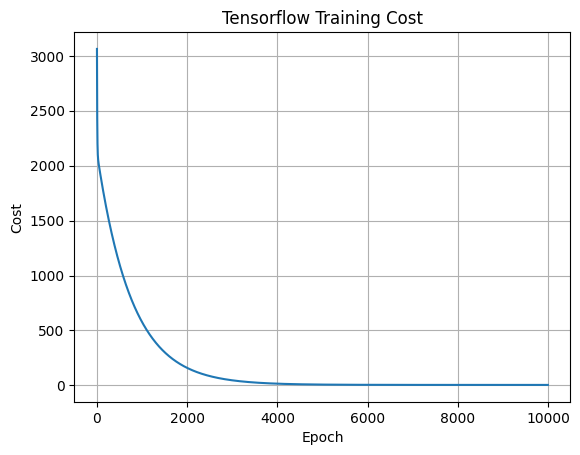

In [10]:
import matplotlib.pyplot as plt

# history.history["loss"]에는 epoch 별 cost 값이 저장되어있음. (TensorFlow2의 Keras API 기본 key 이름은 "loss")
cost_history = history.history["loss"]

plt.figure()
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Tensorflow Training Cost")
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 15ms/step


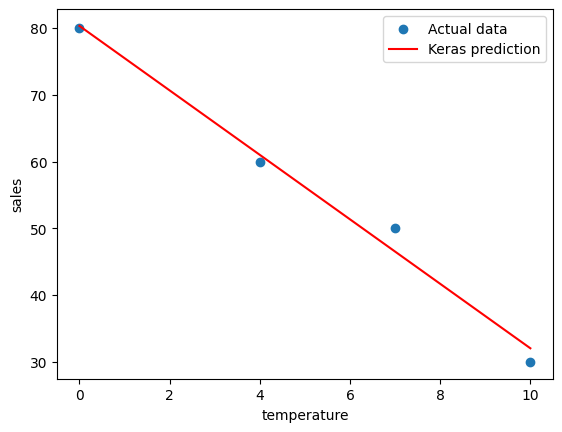

In [12]:
#  model.predict(X)는 학습된 모델로 X에 대한 예측값을 계산
pred_y = model.predict(X)

plt.figure()
plt.scatter(X, y, label = "Actual data")
plt.plot(X, pred_y, color = "red", label = "Keras prediction")
plt.xlabel("temperature")
plt.ylabel("sales")
plt.legend()                 #plt.legend 는 차트 상에 범례를 표시할 때 사용
plt.show()

In [13]:
#새로운 입력값은 2차원 형태로 넣습니다. (행 1개, 열 1개)
new_temperature = np.array([[5]], dtype = "float32")
pred_sales = model.predict(new_temperature)

print(f"기온이 5도 일 때 예상 판매량: {pred_sales[0][0]:.2f}개")

1/1 [==============================] - 0s 14ms/step
기온이 5도 일 때 예상 판매량: 56.17개
